**BASELINE LINEAR REGRESSION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_csv("housing.csv")

print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [3]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [4]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [5]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

In [9]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 4908476721.156637
RMSE: 70060.52184473534
MAE : 50670.73824097196
R²  : 0.625424062055359


In [10]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

     Actual      Predicted
0   47700.0   54055.448899
1   45800.0  124225.338937
2  500001.0  255489.379492
3  218600.0  268002.431569
4  278000.0  262769.434816
5  158700.0  139606.303956
6  198200.0  290665.423914
7  157500.0  228264.876375
8  340000.0  256506.785610
9  446600.0  407923.858435


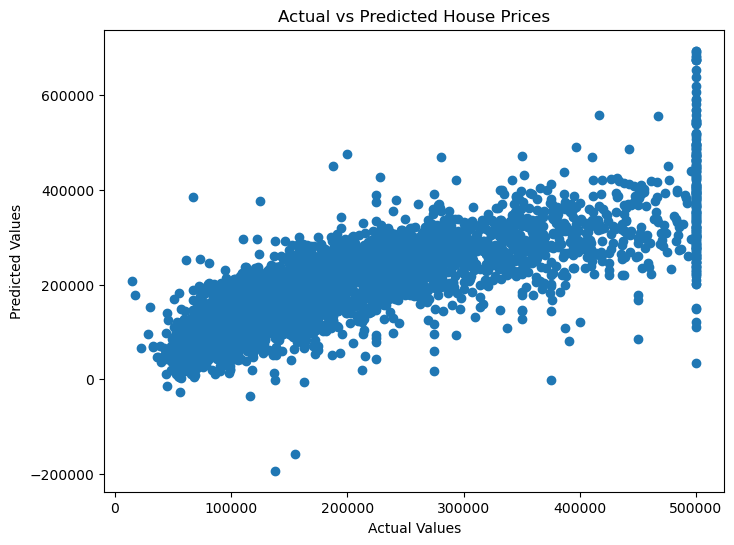

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")

plt.show()

**ONE FEATURE VS MULTI FEATURE**

In [13]:
#Model A
df.head

<bound method NDFrame.head of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  ho

In [14]:
X1 = df[["median_income"]]

X1_train, X1_test, y_train, y_test = train_test_split(
    X1,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model_A = LinearRegression()

model_A.fit(X1_train, y_train)

pred_A = model_A.predict(X1_test)

In [16]:
#MODEL B (Multi Feature)
X2 = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms"
    ]
]

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model_B = LinearRegression()

model_B.fit(X2_train, y_train)

pred_B = model_B.predict(X2_test)

In [18]:
def evaluate(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return [mse, rmse, mae, r2]

In [19]:
results = pd.DataFrame(
    {
        "Metric":["MSE","RMSE","MAE","R²"],
        "Model A":evaluate(y_test,pred_A),
        "Model B":evaluate(y_test,pred_B)
    }
)

print(results)

  Metric       Model A       Model B
0    MSE  7.091158e+09  6.563179e+09
1   RMSE  8.420901e+04  8.101345e+04
2    MAE  6.299087e+04  6.034804e+04
3     R²  4.588592e-01  4.991504e-01


In [20]:
print("""
Model B performed better because it uses multiple
important features and achieved lower errors and
higher R² on the test set.
""")


Model B performed better because it uses multiple
important features and achieved lower errors and
higher R² on the test set.



**DIFFERENT TRAIN-TEST SPLITS**

In [21]:
def run_split(test_size):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return [
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_r2,
        test_r2
    ]

In [22]:
results = pd.DataFrame(
    [
        ["80/20"] + run_split(0.2),
        ["70/30"] + run_split(0.3),
        ["60/40"] + run_split(0.4)
    ],
    columns=[
        "Split",
        "Train MSE",
        "Test MSE",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train R²",
        "Test R²"
    ]
)

print(results)

   Split     Train MSE      Test MSE    Train RMSE     Test RMSE  \
0  80/20  4.683204e+09  4.908477e+09  68433.937367  70060.521845   
1  70/30  4.728483e+09  4.733529e+09  68763.969068  68800.648784   
2  60/40  4.657887e+09  4.842234e+09  68248.714611  69586.162142   

      Train MAE      Test MAE  Train R²   Test R²  
0  49594.842095  50670.738241  0.649665  0.625424  
1  49723.370211  50078.098842  0.647048  0.639361  
2  49247.528843  50591.220050  0.648915  0.638290  


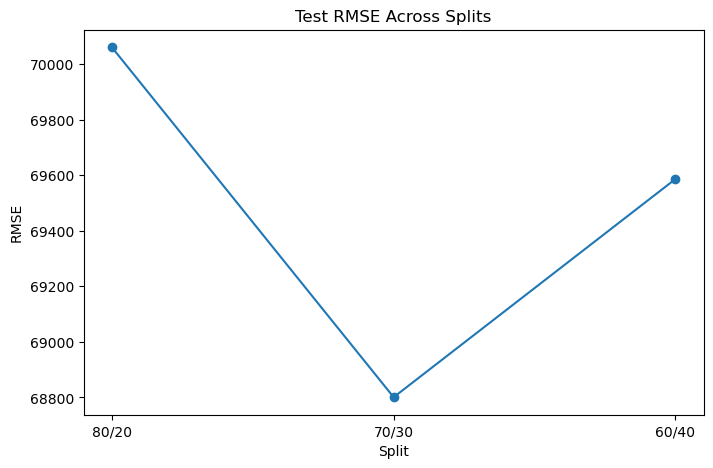

In [23]:
plt.figure(figsize=(8,5))

plt.plot(results["Split"],
         results["Test RMSE"],
         marker="o")

plt.title("Test RMSE Across Splits")

plt.xlabel("Split")
plt.ylabel("RMSE")

plt.show()

In [24]:
best_split = results.loc[
    results["Test R²"].idxmax(),
    "Split"
]

print("Most reliable split:", best_split)

Most reliable split: 70/30


**METRIC VERIFICATION**

In [25]:
manual_mse = np.mean((y_test - y_pred)**2)

print(manual_mse)

4908476721.156637


In [26]:
manual_rmse = np.sqrt(manual_mse)

print(manual_rmse)

70060.52184473534


In [27]:
manual_mae = np.mean(np.abs(y_test - y_pred))

print(manual_mae)

50670.73824097196


In [28]:
ss_res = np.sum((y_test-y_pred)**2)

ss_tot = np.sum(
    (y_test-np.mean(y_test))**2
)

manual_r2 = 1 - (ss_res/ss_tot)

print(manual_r2)

0.625424062055359


In [29]:
from sklearn.metrics import median_absolute_error

medae = median_absolute_error(
    y_test,
    y_pred
)

print(medae)

38377.262951616896


In [30]:
metrics_table = pd.DataFrame({
    "Metric":[
        "MSE",
        "RMSE",
        "MAE",
        "R²",
        "Median AE"
    ],
    "Value":[
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2,
        medae
    ]
})

print(metrics_table)

      Metric         Value
0        MSE  4.908477e+09
1       RMSE  7.006052e+04
2        MAE  5.067074e+04
3         R²  6.254241e-01
4  Median AE  3.837726e+04


In [31]:
modified_pred = y_pred.copy()

modified_pred[:3] += 300000

In [32]:
before = [
    mean_squared_error(y_test,y_pred),
    np.sqrt(mean_squared_error(y_test,y_pred)),
    mean_absolute_error(y_test,y_pred)
]

after = [
    mean_squared_error(y_test,modified_pred),
    np.sqrt(mean_squared_error(y_test,modified_pred)),
    mean_absolute_error(y_test,modified_pred)
]

comparison = pd.DataFrame({
    "Metric":["MSE","RMSE","MAE"],
    "Before":before,
    "After":after
})

print(comparison)

  Metric        Before         After
0    MSE  4.908477e+09  4.950667e+09
1   RMSE  7.006052e+04  7.036098e+04
2    MAE  5.067074e+04  5.077030e+04


In [33]:
print("""
MSE reacted the most strongly because
the errors are squared.

RMSE also increased significantly because
it is based on MSE.

MAE increased but less dramatically because
it treats all errors linearly.

Therefore, MSE is the most sensitive metric
to large prediction errors.
""")


MSE reacted the most strongly because
the errors are squared.

RMSE also increased significantly because
it is based on MSE.

MAE increased but less dramatically because
it treats all errors linearly.

Therefore, MSE is the most sensitive metric
to large prediction errors.

